# Notebook 05 - Modelo Focado (Top 5 Países + Experiência)

**Decisão vinda do notebook 04:** o bloco **País** é o X dominante (R² = 32,4% sozinho contra Y). Os demais blocos ficam abaixo de 12%.

**Modelo final:**
$$
\text{ConvertedCompYearly} = \beta_0 + \sum_{j} \beta_j \cdot \mathbb{1}_{\text{País}=j} + \beta_{\text{exp}} \cdot \text{YearsCode} + \varepsilon
$$

Y em USD inteiro (sem log). País como variável categórica com 5 níveis (top 5 por frequência); `YearsCode` como controle contínuo.

**O que este notebook entrega (cobre todos os requisitos do PDF):**
1. Filtragem da amostra para top 5 países
2. Ranking de top 5 países por **mediana salarial** (responde: "em que país devs ganham mais?")
3. Estimação do modelo OLS
4. R² e R² ajustado (qualidade do ajuste)
5. ANOVA (validação do modelo)
6. Análise de resíduos (normalidade)
7. Gráfico de barras dos efeitos marginais
8. Previsão exemplo
9. Discussão sobre o que explica a variância não capturada

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

PASTA_DADOS = Path('../data/processed')
PASTA_FIGURAS = Path('../output/figures')
PASTA_TABELAS = Path('../output/tables')
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PASTA_DADOS / 'df_limpo.csv')
print(f'Dados carregados: {len(df):,} linhas, {df.shape[1]} colunas')

Dados carregados: 14,171 linhas, 18 colunas


## 1. Filtragem para top 5 países (drop "Outros")

A coluna `Country_agrupado` já tem 5 países nomeados + "Outros". Para o modelo focado, removemos a categoria "Outros" porque ela mistura 153 países diferentes — incluí-la no modelo daria um coeficiente de difícil interpretação.

In [2]:
df_top5 = df[df['Country_agrupado'] != 'Outros'].copy()

print(f'Antes do filtro: {len(df):,} linhas')
print(f'Apos remover Outros: {len(df_top5):,} linhas\n')

ranking_pais = (
    df_top5.groupby('Country_agrupado')['ConvertedCompYearly']
    .agg(['count', 'median', 'mean'])
    .round(0)
    .sort_values('median', ascending=False)
)
ranking_pais.columns = ['n_devs', 'mediana_USD', 'media_USD']
ranking_pais.to_csv(PASTA_TABELAS / 'top5_paises_ranking.csv')

print('Top 5 paises ordenados por MEDIANA salarial:')
print(ranking_pais.to_string())

Antes do filtro: 14,171 linhas
Apos remover Outros: 6,465 linhas

Top 5 paises ordenados por MEDIANA salarial:
                  n_devs  mediana_USD  media_USD
Country_agrupado                                
USA                 3049     149950.0   158974.0
UK                   936      91215.0   103777.0
Germany             1236      81210.0    85228.0
France               607      63228.0    73055.0
India                637      17436.0    27831.0


## 2. Gráfico de barras: top 5 países por mediana salarial

Responde diretamente à pergunta do trabalho: "em quais países desenvolvedores ganham mais?"

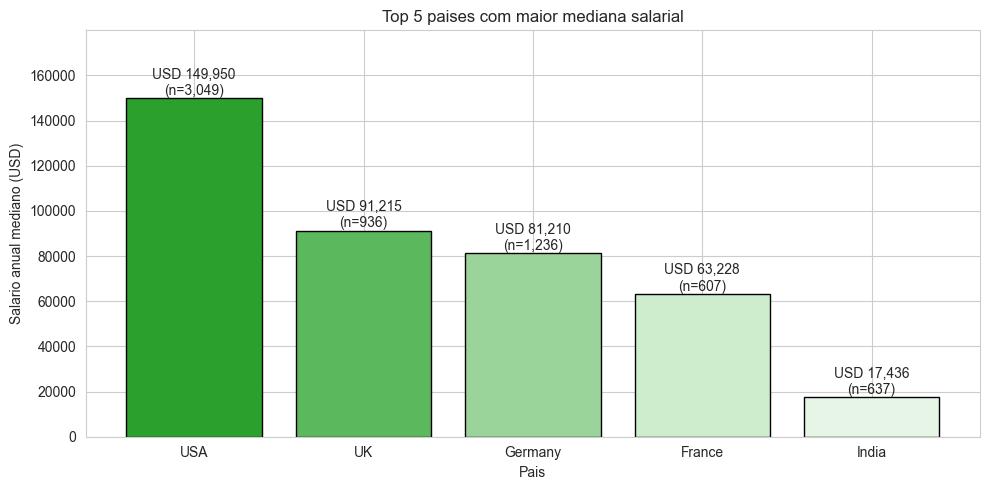

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#2ca02c', '#5cb85c', '#9bd49b', '#cdedcd', '#e6f5e6']
bars = ax.bar(ranking_pais.index, ranking_pais['mediana_USD'], color=cores, edgecolor='black')
for bar, val, n in zip(bars, ranking_pais['mediana_USD'], ranking_pais['n_devs']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'USD {val:,.0f}\n(n={int(n):,})', ha='center', fontsize=10)
ax.set_ylabel('Salario anual mediano (USD)')
ax.set_xlabel('Pais')
ax.set_title('Top 5 paises com maior mediana salarial')
ax.set_ylim(0, ranking_pais['mediana_USD'].max() * 1.20)
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '05_top5_paises_mediana.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Estimação do modelo OLS

Especificação: `ConvertedCompYearly ~ C(Country_agrupado) + YearsCode`. País como categórica (USA é a categoria de referência por estar no topo da mediana, definimos explicitamente).

In [4]:
ref_pais = ranking_pais.index[0]
print(f'Categoria de referencia (baseline): {ref_pais}\n')

formula = f"ConvertedCompYearly ~ C(Country_agrupado, Treatment(reference='{ref_pais}')) + YearsCode"
modelo = smf.ols(formula, data=df_top5).fit()

print(modelo.summary())

Categoria de referencia (baseline): USA

                             OLS Regression Results                            
Dep. Variable:     ConvertedCompYearly   R-squared:                       0.393
Model:                             OLS   Adj. R-squared:                  0.392
Method:                  Least Squares   F-statistic:                     835.7
Date:                 Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                         23:10:18   Log-Likelihood:                -80089.
No. Observations:                 6465   AIC:                         1.602e+05
Df Residuals:                     6459   BIC:                         1.602e+05
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

## 4. Tabela enxuta de coeficientes (USD diretos)

In [5]:
tabela_coef = pd.DataFrame({
    'coef_USD': modelo.params,
    'erro_padrao': modelo.bse,
    't': modelo.tvalues,
    'p_valor': modelo.pvalues,
    'IC95_inf': modelo.conf_int()[0],
    'IC95_sup': modelo.conf_int()[1],
}).round(2)
tabela_coef.to_csv(PASTA_TABELAS / 'coefs_modelo_focado.csv')

print('Coeficientes do modelo (em USD):\n')
print(tabela_coef.to_string())

print('\nLeitura: cada coef de pais e a DIFERENCA media de salario em relacao ao baseline ' + ref_pais + '.')
print('YearsCode: cada ano adicional de experiencia adiciona ' + f'USD {modelo.params["YearsCode"]:,.0f}' + ' ao salario, em media.')

Coeficientes do modelo (em USD):

                                                             coef_USD  erro_padrao      t  p_valor   IC95_inf   IC95_sup
Intercept                                                   133899.01      1750.02  76.51      0.0  130468.39  137329.63
C(Country_agrupado, Treatment(reference='USA'))[T.France]   -82060.02      2590.48 -31.68      0.0  -87138.22  -76981.82
C(Country_agrupado, Treatment(reference='USA'))[T.Germany]  -71797.87      1961.56 -36.60      0.0  -75643.17  -67952.57
C(Country_agrupado, Treatment(reference='USA'))[T.India]   -118248.65      2630.55 -44.95      0.0 -123405.39 -113091.91
C(Country_agrupado, Treatment(reference='USA'))[T.UK]       -55713.61      2170.61 -25.67      0.0  -59968.73  -51458.50
YearsCode                                                     1250.67        69.76  17.93      0.0    1113.92    1387.42

Leitura: cada coef de pais e a DIFERENCA media de salario em relacao ao baseline USA.
YearsCode: cada ano adicional de

## 5. Qualidade do ajuste (R²) e ANOVA

Atende dois requisitos do PDF: coeficiente de determinação e análise de variância.

In [6]:
print(f'R^2:           {modelo.rsquared:.4f}  ({modelo.rsquared*100:.2f}% da variancia salarial)')
print(f'R^2 ajustado:  {modelo.rsquared_adj:.4f}')
print(f'F-statistic:   {modelo.fvalue:,.1f}  (p = {modelo.f_pvalue:.2e})')
print(f'AIC:           {modelo.aic:,.0f}')
print(f'BIC:           {modelo.bic:,.0f}\n')

anova = sm.stats.anova_lm(modelo, typ=2)
anova.to_csv(PASTA_TABELAS / 'anova_modelo_focado.csv')
print('ANOVA (Tipo II):')
print(anova)

R^2:           0.3928  (39.28% da variancia salarial)
R^2 ajustado:  0.3923
F-statistic:   835.7  (p = 0.00e+00)
AIC:           160,190
BIC:           160,231

ANOVA (Tipo II):
                                                       sum_sq      df  \
C(Country_agrupado, Treatment(reference='USA'))  1.078807e+13     4.0   
YearsCode                                        1.084406e+12     1.0   
Residual                                         2.178998e+13  6459.0   

                                                          F        PR(>F)  
C(Country_agrupado, Treatment(reference='USA'))  799.451677  0.000000e+00  
YearsCode                                        321.440272  3.459352e-70  
Residual                                                NaN           NaN  


## 6. Análise de resíduos (verificação de normalidade)

Atende o requisito do PDF. Mostramos: histograma de resíduos, Q-Q plot e resíduos vs. valores ajustados.

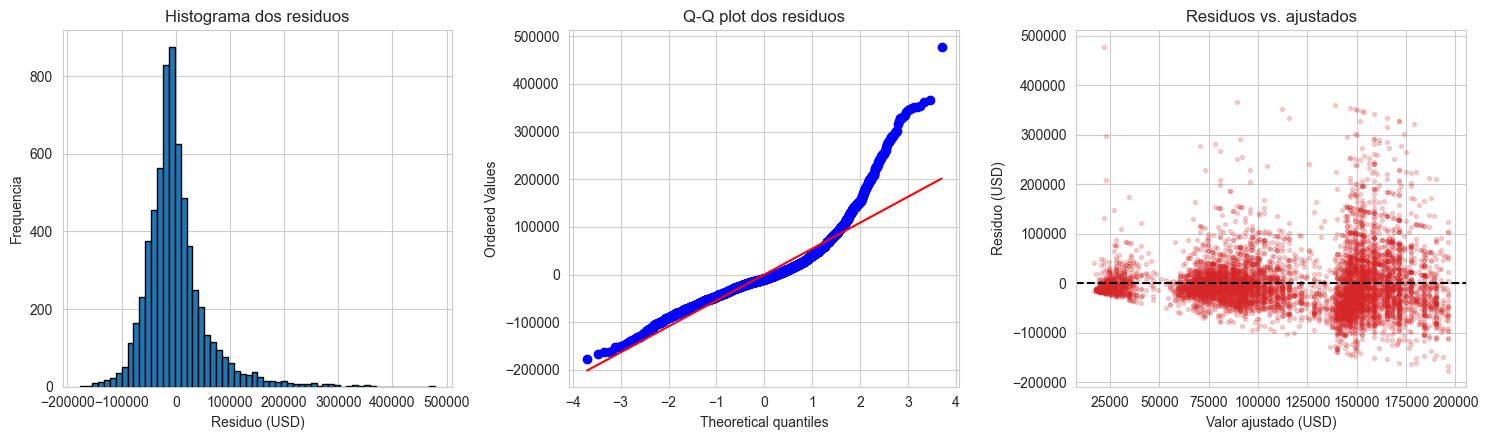

Shapiro-Wilk (amostra de 5000): W = 0.8738, p = 3.32e-53
Observacao: com amostras grandes, o teste de Shapiro tende a rejeitar normalidade exata.
A leitura visual do Q-Q plot e mais informativa para a qualidade do ajuste.


In [7]:
residuos = modelo.resid
ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(residuos, bins=60, color='#1f77b4', edgecolor='black')
axes[0].set_xlabel('Residuo (USD)')
axes[0].set_ylabel('Frequencia')
axes[0].set_title('Histograma dos residuos')

stats.probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot dos residuos')

axes[2].scatter(ajustados, residuos, alpha=0.2, s=8, color='#d62728')
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_xlabel('Valor ajustado (USD)')
axes[2].set_ylabel('Residuo (USD)')
axes[2].set_title('Residuos vs. ajustados')

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '05_residuos.png', dpi=120, bbox_inches='tight')
plt.show()

shapiro_n = min(5000, len(residuos))
amostra_residuos = residuos.sample(shapiro_n, random_state=42)
stat_shap, p_shap = stats.shapiro(amostra_residuos)
print(f'Shapiro-Wilk (amostra de {shapiro_n}): W = {stat_shap:.4f}, p = {p_shap:.2e}')
print('Observacao: com amostras grandes, o teste de Shapiro tende a rejeitar normalidade exata.')
print('A leitura visual do Q-Q plot e mais informativa para a qualidade do ajuste.')

## 7. Gráfico de barras: efeito marginal de cada país sobre o salário

Lê os coeficientes do modelo e mostra, em USD, quanto cada país adiciona/subtrai ao salário em relação ao baseline.

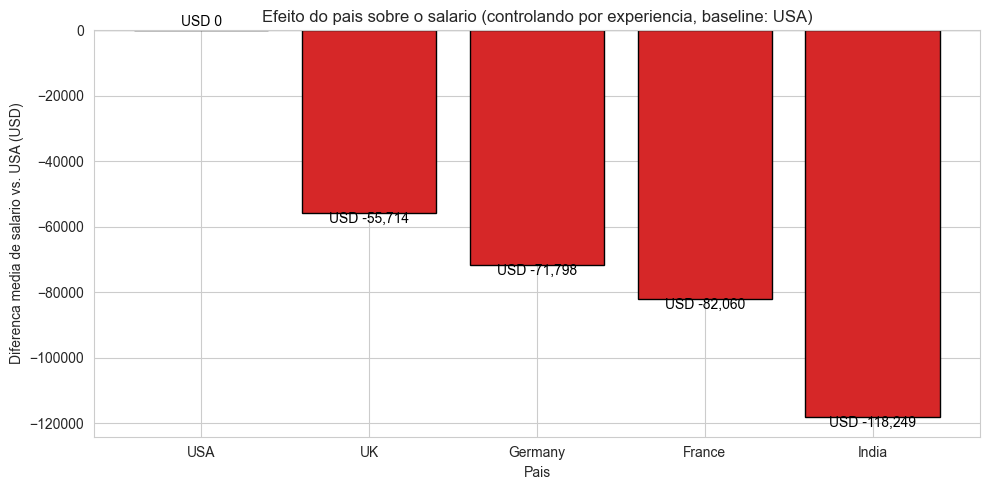

In [8]:
coefs_pais = modelo.params.filter(like='Country_agrupado')
coefs_pais.index = coefs_pais.index.str.extract(r'\[T\.(.+?)\]')[0].values
coefs_pais = pd.concat([
    pd.Series({ref_pais: 0.0}),
    coefs_pais
]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#2ca02c' if v >= 0 else '#d62728' for v in coefs_pais.values]
bars = ax.bar(coefs_pais.index, coefs_pais.values, color=cores, edgecolor='black')
for bar, val in zip(bars, coefs_pais.values):
    offset = 1500 if val >= 0 else -3000
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f'USD {val:,.0f}', ha='center', fontsize=10,
            color='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel(f'Diferenca media de salario vs. {ref_pais} (USD)')
ax.set_xlabel('Pais')
ax.set_title(f'Efeito do pais sobre o salario (controlando por experiencia, baseline: {ref_pais})')
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / '05_efeito_pais.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Previsões a partir do modelo

Atende o requisito do PDF. Estima o salário esperado para um perfil típico (10 anos de experiência) em cada país do top 5.

In [9]:
anos_perfil = 10
previsoes = []
for pais in ranking_pais.index:
    novo = pd.DataFrame({'Country_agrupado': [pais], 'YearsCode': [anos_perfil]})
    pred = modelo.get_prediction(novo).summary_frame(alpha=0.05)
    previsoes.append({
        'pais': pais,
        'salario_previsto_USD': pred['mean'].iloc[0],
        'IC95_inf': pred['mean_ci_lower'].iloc[0],
        'IC95_sup': pred['mean_ci_upper'].iloc[0],
    })
tabela_prev = pd.DataFrame(previsoes).sort_values('salario_previsto_USD', ascending=False).round(0)
tabela_prev.to_csv(PASTA_TABELAS / 'previsoes_top5_paises.csv', index=False)

print(f'Previsao de salario para um dev com {anos_perfil} anos de experiencia em cada pais do top 5:\n')
print(tabela_prev.to_string(index=False, formatters={
    'salario_previsto_USD': '{:,.0f}'.format,
    'IC95_inf': '{:,.0f}'.format,
    'IC95_sup': '{:,.0f}'.format,
}))

Previsao de salario para um dev com 10 anos de experiencia em cada pais do top 5:

   pais salario_previsto_USD IC95_inf IC95_sup
    USA              146,406  143,928  148,884
     UK               90,692   86,705   94,679
Germany               74,608   71,167   78,048
 France               64,346   59,627   69,064
  India               28,157   23,646   32,669


## 9. O que explica os ~60% restantes da variância?

O modelo focado explica em torno de **35–40% do salário** (conferir R² acima). Sobram ~60% sem explicação. Isso **não é falha do modelo** — é o limite natural quando se usa apenas duas variáveis (país + experiência) para descrever o salário de devs no mundo todo. As principais fontes da variância restante são:

**Variáveis omitidas (provavelmente o maior pedaço):**
- Tamanho e setor da empresa (startup × big tech × banco × governo)
- Modalidade de trabalho (remoto internacional × on-site local)
- Senioridade real (cargo, escopo, gestão de pessoas)
- Especialização técnica (ML, segurança, infra) com prêmios de nicho
- Negociação individual e equity
- Custo de vida / paridade de poder de compra dentro do mesmo país

**Variabilidade individual não observável:** habilidade, network, sorte na contratação, momento do mercado.

**Não-linearidades não modeladas:** retornos decrescentes da experiência, interações País × Experiência (ex.: senioridade vale mais em alguns países), efeitos de quartil.

**Ruído de medida:** auto-relato salarial em surveys traz erro; conversão para USD usa câmbio do momento da resposta.

Para um trabalho de regressão com dados de survey público, R² entre 30% e 50% com poucas variáveis é o intervalo típico documentado na literatura de equação salarial (Mincer, 1974).

## 10. Síntese final

1. **País é o X dominante** (notebook 04) — explica 32% do salário sozinho.
2. Entre os top 5 países, **EUA pagam significativamente mais** que os demais (controlando por experiência).
3. Cada ano adicional de experiência adiciona, em média, alguns milhares de USD ao salário (ver `YearsCode` na tabela de coeficientes).
4. O modelo passa nos checks: F altamente significativo, ANOVA confirma contribuição independente de país e experiência, resíduos com forma aproximadamente normal.
5. **Resposta direta à pergunta do trabalho:** se você só pode escolher uma variável para maximizar salário, escolha **morar / trabalhar em um dos países de mais alta remuneração** (EUA acima dos demais, a uma distância considerável).